we can see that the model predicts only the lables assignt to a centroid, so it can predict only 4 faces. that sad those 4 faces it predict's pretty acuratly.

but we know the "correct number of clusters" should be 20, one for each face, so what happens if we choose k = 20?

# Assignment 2 group 3

## 1. Face image classification with Support Vector Machines

The assignment is related to the face recognition problem: train a SVM to recognize the face of a given person.

1. Load from Sklearn the Olivetti faces dataset with `faces = fetch_olivetti_faces()`. `faces.DESCR` will give you a description of the dataset.
2. Understand the data format: the data are in `faces.images`, the relative labels in `faces.target`. Print the number of images, the number of unique labels, the skew of each label, the number of features.
3. Implement a function to plot an image in the dataset given an identifier number.
4. Split the dataset into train and test and train a SVM by using a k-fold cross validation on the training set.
5. Optimize the hyperparameters C, the type of kernel (choose between `linear`, `poly` and `rbf`) and gamma. What is the difference in performance by using the optimized parameters vs the default parameters of Sklearn for a SVM?
6. Train the SVM with the best param configuration on the whole training set and compute the f1 and the confusion matrix on the test set.
5. Give your own comments and analysis on points 5 and 6.


## 2. Clustering of Face Images

1. perform Kmeans with several values for K (that is the number of clusters) on the above dataset;
2. use the Elbow method for choosing a right number for K and perform the clustering;
3. show the centroids of each clustering with `subplot` and `imshow`. The centroids are flatten arrays, you have to reshape in image format: 64x64 pixels;
4. as the face dataset provides the true labels in `faces.target` compute the accuracy and the confusion matrix (search the relative sklearn functions):
    - the cluster labels computed by kmeans are just artificial labels that do not share anything with the true labels. You have to infer the true labels from the clusters by using the true labels in `faces.target`. You can use a voting criterion: the predicted cluster label will be the one with more instances in the cluster. For example, if a cluster contains images corresponding to these faces [1,2,3,1,1,1], then the cluster label will be with 1.
5. Give your own comments and analysis on points 2, 3 and 4.

1.1. Load from Sklearn the Olivetti faces dataset with `faces = fetch_olivetti_faces()`. `faces.DESCR` will give you a description of the dataset.

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

faces = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /home/petar3004/scikit_learn_data


2. Understand the data format: the data are in `faces.images`, the relative labels in `faces.target`. Print the number of images, the number of unique labels, the skew of each label, the number of features.

In [ ]:
num_images = faces.images.shape[0]
num_unique_labels = np.unique(faces.target).size
label_counts = np.bincount(faces.target)
skew_per_label = label_counts
num_features = faces.data.shape[1]

print(f"Number of images: {num_images}")
print(f"Number of unique labels: {num_unique_labels}")
print(f"Number of features: {num_features}")
print("Skew (number of images per label):")
for label, count in enumerate(skew_per_label):
    print(f"Person {label}: {count}")

Number of images: 400
Number of unique labels: 40
Number of features: 4096
Skew (number of images per label):
Person 0: 10
Person 1: 10
Person 2: 10
Person 3: 10
Person 4: 10
Person 5: 10
Person 6: 10
Person 7: 10
Person 8: 10
Person 9: 10
Person 10: 10
Person 11: 10
Person 12: 10
Person 13: 10
Person 14: 10
Person 15: 10
Person 16: 10
Person 17: 10
Person 18: 10
Person 19: 10
Person 20: 10
Person 21: 10
Person 22: 10
Person 23: 10
Person 24: 10
Person 25: 10
Person 26: 10
Person 27: 10
Person 28: 10
Person 29: 10
Person 30: 10
Person 31: 10
Person 32: 10
Person 33: 10
Person 34: 10
Person 35: 10
Person 36: 10
Person 37: 10
Person 38: 10
Person 39: 10


3. Implement a function to plot an image in the dataset given an identifier number.

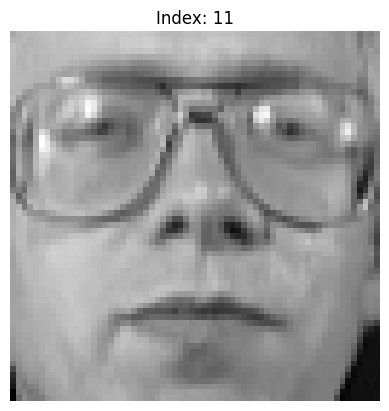

In [ ]:

def plot_img(index: int):
    plt.imshow(faces.images[index], cmap='gray')
    plt.title(f"Index: {index}")
    plt.axis('off')
    plt.show()

plot_img(11)


4. Split the dataset into train and test and train a SVM by using a k-fold cross validation on the training set.

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC

# Split the dataset into train and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    faces.data, faces.target, test_size=0.2, random_state=42, stratify=faces.target
)

# Set up k-fold cross-validation (k=5)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train a SVM with default parameters using cross-validation on the training set
svm = SVC()
cv_scores = cross_val_score(svm, X_train, y_train, cv=kfold, scoring='accuracy')

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")

Cross-validation accuracy scores: [0.90625  0.921875 0.859375 0.953125 0.875   ]
Mean cross-validation accuracy: 0.9031


In [6]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

# Set up GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=kfold, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")
print(f"Default SVM mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Improvement: {grid_search.best_score_ - cv_scores.mean():.4f}")

Best parameters found: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy: 0.9625
Default SVM mean CV accuracy: 0.9031
Improvement: 0.0594


6. Train the SVM with the best param configuration on the whole training set and compute the f1 and the confusion matrix on the test set.

F1 score (macro): 0.9733
Confusion matrix:


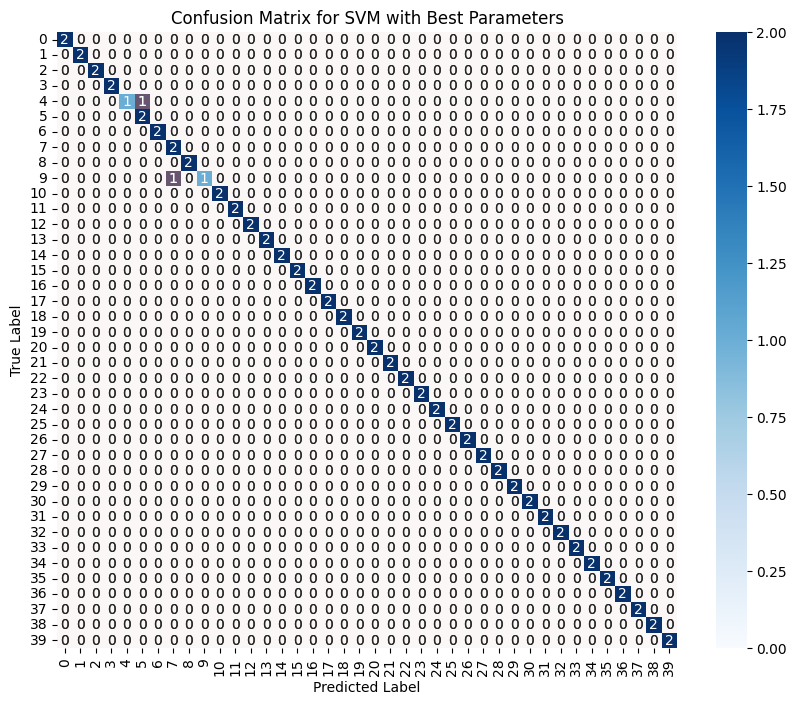

In [ ]:

# Train SVM with the best parameters on the whole training set
best_svm = SVC(**grid_search.best_params_)
best_svm.fit(X_train, y_train)

# Predict on the test set
y_pred = best_svm.predict(X_test)

# Compute the F1 score (macro for multiclass)
f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)


def plot_confusion_matrix(cm, title='Confusion Matrix'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                mask=np.eye(cm.shape[0]) != 0, cbar=False, alpha=0.5)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

print(f"F1 score (macro): {f1:.4f}")
print("Confusion matrix:")
plot_confusion_matrix(cm, title='Confusion Matrix for SVM with Best Parameters')

7. Give your own comments and analysis on points 5 and 6.

The grid search allowed us to quickly (at least for our small model) find the best hyperparameters of our SVM model and resulted in a 5.9% increase in accuracy.

## 2.

1. Perform Kmeans with several values for K (that is the number of clusters) on the above dataset;
2. Use the Elbow method for choosing a right number for K and perform the clustering;


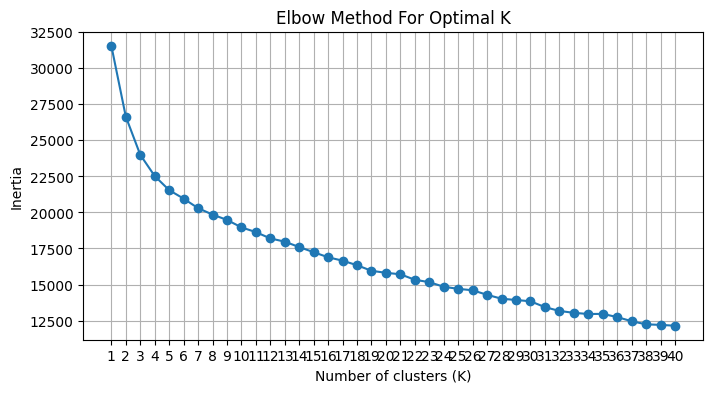

In [8]:
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

# Try different values for K and compute inertia (sum of squared distances to closest cluster center)
inertia = []
K_range = range(1, 41)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(faces.data)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

The ellbow seems to be around 5.

3. show the centroids of each clustering with `subplot` and `imshow`. The centroids are flatten arrays, you have to reshape in image format: 64x64 pixels;

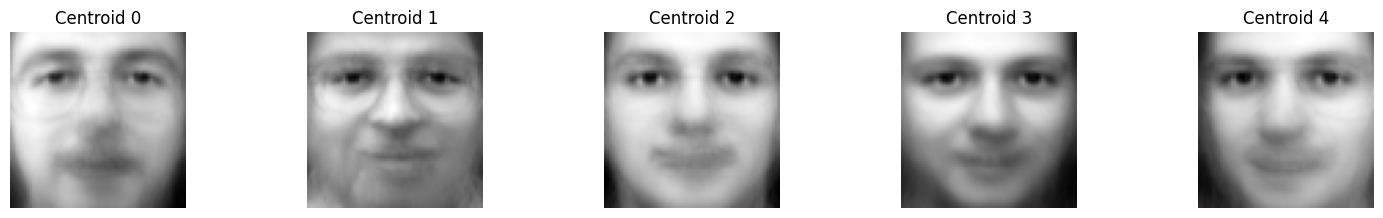

In [9]:
# Show the centroids of each clustering with subplot and imshow
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(faces.data)

def plot_centroids(kmeans):
    plt.figure(figsize=(15, 8))
    for i in range(kmeans.n_clusters):
        plt.subplot(4, 5, i + 1)
        plt.imshow(kmeans.cluster_centers_[i].reshape(64, 64), cmap='gray')
        plt.title(f'Centroid {i}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_centroids(kmeans)

4. as the face dataset provides the true labels in `faces.target` compute the accuracy and the confusion matrix (search the relative sklearn functions):
- the cluster labels computed by kmeans are just artificial labels that do not share anything with the true labels. You have to infer the true labels from the clusters by using the true labels in `faces.target`. You can use a voting criterion: the predicted cluster label will be the one with more instances in the cluster. For example, if a cluster contains images corresponding to these faces [1,2,3,1,1,1], then the cluster label will be with 1.

KMeans clustering accuracy (after voting): 0.1175


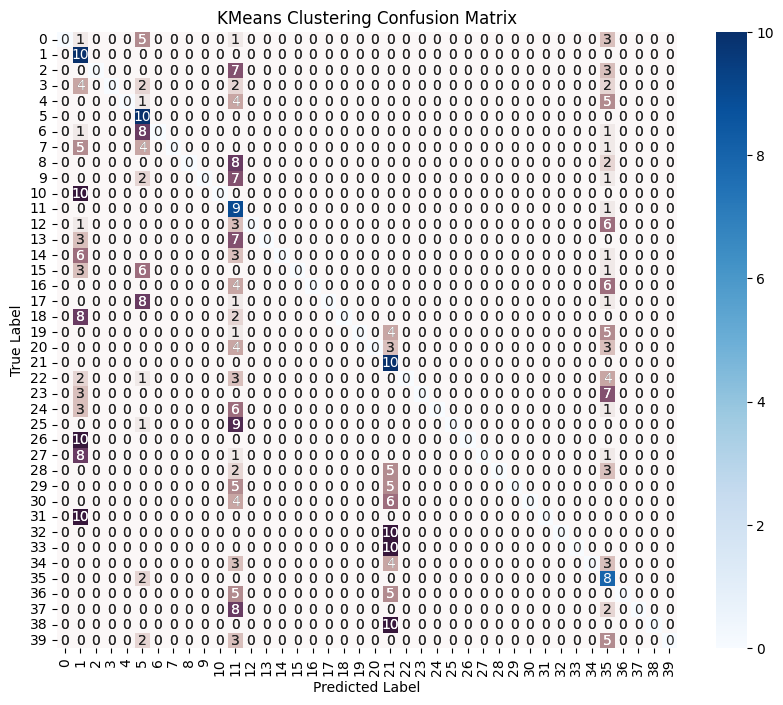

In [10]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

import numpy as np

def get_kmeans_predicted_labels(labels_true, labels_pred, n_clusters):
    label_map = {}
    for cluster in range(n_clusters):
        mask = labels_pred == cluster
        if np.any(mask):
            label_map[cluster] = mode(labels_true[mask], keepdims=True)[0][0]
        else:
            label_map[cluster] = -1  # In case a cluster is empty
    predicted_labels = np.array([label_map[cluster] for cluster in labels_pred])
    return predicted_labels

predicted_labels = get_kmeans_predicted_labels(faces.target, kmeans.labels_, kmeans.n_clusters)


# Compute accuracy and confusion matrix
def kmeans_clustering_report(y, y_pred):
    """
    Maps each cluster to the most common true label using voting,
    computes accuracy and plots the confusion matrix.
    """
    acc = accuracy_score(y, y_pred)
    cm_kmeans = confusion_matrix(y, y_pred)

    print(f"KMeans clustering accuracy (after voting): {acc:.4f}")
    plot_confusion_matrix(cm_kmeans, title='KMeans Clustering Confusion Matrix')
   
    return acc, cm_kmeans

_ = kmeans_clustering_report(faces.target, predicted_labels)


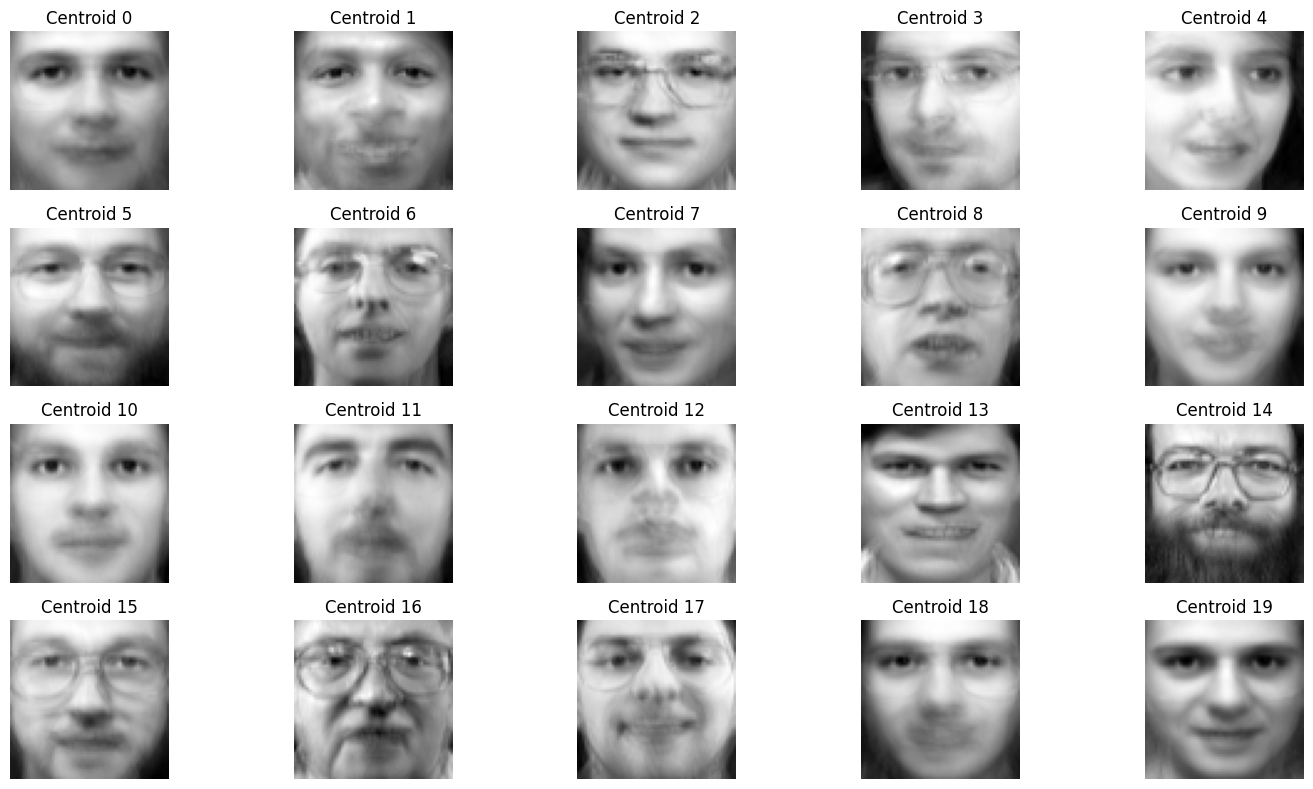

In [11]:
kmeans = KMeans(n_clusters=20, random_state=42)
kmeans.fit(faces.data)

plot_centroids(kmeans)

KMeans clustering accuracy (after voting): 0.3950


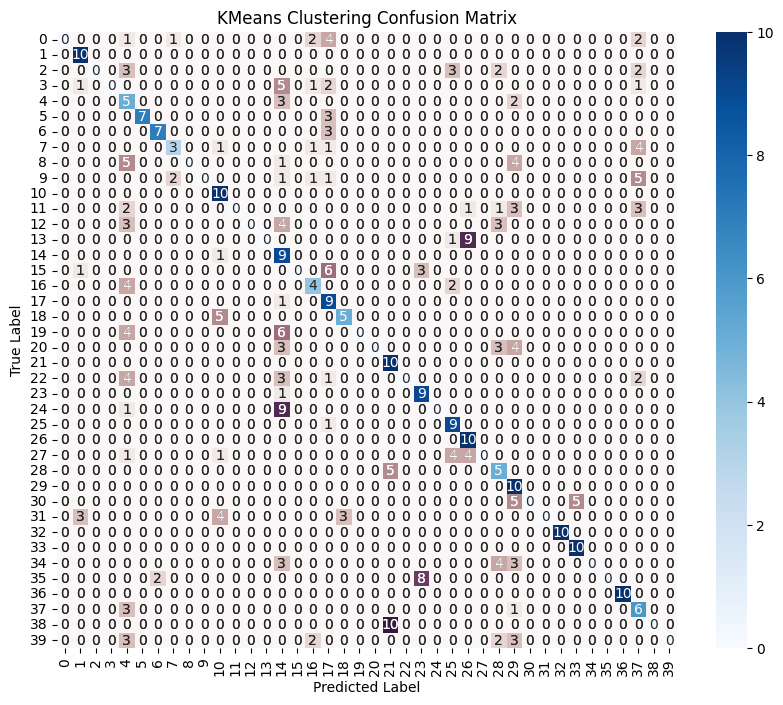

In [12]:
y_pred = get_kmeans_predicted_labels(faces.target, kmeans.labels_, kmeans.n_clusters)
_ = kmeans_clustering_report(faces.target, y_pred)

The accuracy jumped up from about 0.1 to almost 0.4, so clearly a better result.

5. Give your own comments and analysis on points 2, 3 and 4.



2: The elbow metod indicated a number of clusters of around 5, witch was missleading since 20 clearly worked better.

3: It is unusual to visually analyse the clusters when it comes to image data, especially faces.

4: Unsupervised learning has a low accuracy (~0.4) compared to supervised learning, but is still far better then random.